In [1]:
# 导入必要的库
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import torch.nn.functional as F

In [2]:
# 检查CUDA是否可用
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
random.seed(42)

Main_path='D:\\Desktop\\Desktop\\Python\\Forward_and_Inverse_problem\\'

save_path = f'{Main_path}Model\\Python_code_FFT_Complex\\Forward_problem\\'

Excitation_signal_path = f'{Main_path}Data\\Hanning_Excitation_signal'
experimental_signal_path = f'{Main_path}Data\\Experiment_signal'

Using device: cuda:0


In [3]:
M = 9900
batch_size = 32
label_dim = 3

criterion = nn.MSELoss().to(device)

# 定义数据集类
class SignalDataset(Dataset):
    def __init__(self, excitation_signals, labels, experimental_signal):
        self.excitation_signals = torch.tensor(excitation_signals, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.experimental_signal = torch.tensor(experimental_signal, dtype=torch.float32)

    def __len__(self):
        return len(self.excitation_signals)

    def __getitem__(self, idx):
        return {
            'excitation_signal': self.excitation_signals[idx],
            'labels': self.labels[idx],
            'experimental_signal': self.experimental_signal[idx]
        }

In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, signal_length, label_dim, hidden_dim, dropout):
        super().__init__()
        self.signal_length = signal_length
        self.label_dim = label_dim
        
        # 标签投影网络（7层）
        self.label_projection = nn.Sequential(
            nn.Linear(label_dim, hidden_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim * 8),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 8, hidden_dim * 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 16, hidden_dim * 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 32, hidden_dim * 64),  # 第5层
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 64, hidden_dim * 128), # 第6层
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 128, hidden_dim * 64) # 第7层

        )
        
        # 7层编码器
        self.encoder = nn.Sequential(
            # Layer 1
            nn.Conv1d(1, hidden_dim, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            
            # Layer 2
            nn.Conv1d(hidden_dim, hidden_dim*2, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            
            # Layer 3
            nn.Conv1d(hidden_dim*2, hidden_dim*4, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Layer 4
            nn.Conv1d(hidden_dim*4, hidden_dim*8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Layer 5
            nn.Conv1d(hidden_dim*8, hidden_dim*16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Layer 6
            nn.Conv1d(hidden_dim*16, hidden_dim*32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Layer 7
            nn.Conv1d(hidden_dim*32, hidden_dim*64, kernel_size=3, stride=1, padding=1)
        )
        
        # 7层解码器
        self.decoder = nn.Sequential(
            # Layer 1: 融合
            nn.ConvTranspose1d(hidden_dim*64 + hidden_dim*64, hidden_dim*32,  # 标签特征改为64维
                              kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Layer 2
            nn.ConvTranspose1d(hidden_dim*32, hidden_dim*16, 
                              kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Layer 3
            nn.ConvTranspose1d(hidden_dim*16, hidden_dim*8, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Layer 4
            nn.ConvTranspose1d(hidden_dim*8, hidden_dim*4, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Layer 5
            nn.ConvTranspose1d(hidden_dim*4, hidden_dim*2, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Layer 6
            nn.ConvTranspose1d(hidden_dim*2, hidden_dim, 
                              kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            
            # Layer 7
            nn.ConvTranspose1d(hidden_dim, 1, 
                              kernel_size=7, stride=2, padding=3, output_padding=1),
        )
        
        # 计算编码输出长度
        with torch.no_grad():
            test_input = torch.randn(1, 1, signal_length)
            encoded = self.encoder(test_input)
            self.encoder_output_len = encoded.shape[-1]

    def forward(self, x, labels):
        # 编码
        encoded = self.encoder(x)
        
        # 标签特征
        label_features = self.label_projection(labels)
        label_features = label_features.unsqueeze(-1).expand(-1, -1, self.encoder_output_len)
        
        # 融合和解码
        combined = torch.cat([encoded, label_features], dim=1)
        decoded = self.decoder(combined)
        
        return decoded[:,:,:self.signal_length]

In [5]:
def load_data(excitation_signal_path, experimental_signal_path, M):
    excitation_signals = []  # 存储生成信号
    labels = []  # 存储标签 (Force_label, HI_label, Distance_label, Time_label)
    experimental_signals = []  # 存储输出参数

    # 加载生成信号数据
    excitation_dataPaths = sorted(glob.glob(os.path.join(excitation_signal_path, '**', '*.csv'), recursive=True))
    for dataPath in excitation_dataPaths:
        filename = os.path.basename(dataPath)
        parts = filename.split('_')

        Temperature_label = float(parts[0])
        Time_label = float(parts[1])
        Distance_label = float(parts[4])
        amp_part = parts[5].replace('.csv', '')
        Amp_label = float(amp_part)    

        data_1 = pd.read_csv(dataPath)
        # 找到第一个非0值的位置
        for N in range(len(data_1)):
            if data_1.iloc[N, 1] != 0:
                break
        # 截取长度为M的信号段
        if N + M <= len(data_1):  # 避免越界
            excitation_signal = data_1.iloc[N:N+M, 1].values*Amp_label
        else:
            continue

        # 分别存储 excitation_signal 和 labels
        excitation_signals.append(excitation_signal)
        labels.append([Temperature_label, Time_label, Distance_label])

    # 加载实验信号数据
    experimental_dataPaths = sorted(glob.glob(os.path.join(experimental_signal_path, '**', '*.csv'), recursive=True))
    for dataPath in experimental_dataPaths:
        data_1 = pd.read_csv(dataPath)
        # 找到第一个非0值的位置
        for N in range(len(data_1)):
            if data_1.iloc[N, 1] != 0:
                break
        # 截取长度为M的信号段(避免越界）
        if N + M <= len(data_1):
            experimental_signal = data_1.iloc[N:N+M, 1].values
            experimental_signals.append(experimental_signal)
        else:
            # 如果长度不足，跳过该样本
            continue

    # 确保 excitation_signals、labels 和 experimental_signals 的长度一致
    if len(excitation_signals) != len(experimental_signals) or len(labels) != len(experimental_signals):
        print(f"Error: 输入输出数量不匹配！生成信号数:{len(excitation_signals)}, 实验信号数:{len(experimental_signals)}, 标签数:{len(labels)}")
        return None, None, None, None, None

    # 转换为 NumPy 数组
    excitation_signals = np.array(excitation_signals, dtype=float)
    labels = np.array(labels, dtype=float)
    experimental_signals = np.array(experimental_signals, dtype=float)

    return excitation_signals, labels, experimental_signals

In [6]:
# 2. 一次性加载全部数据
excitation_signals, labels, experimental_signal= load_data(
    Excitation_signal_path, experimental_signal_path, M)

# 3. 第一次划分：先劈出test_size测试集，剩下 1-test_size留给训练+验证
gen_train_val, gen_test, lab_train_val, lab_test, exp_train_val, exp_test = train_test_split(
    excitation_signals, labels, experimental_signal,
    test_size=8/10, random_state=42, shuffle=True)

# 4. 第二次划分：test_size为验证集数据占比，1-test_size为训练集数据占比
gen_train, gen_val, lab_train, lab_val, exp_train, exp_val = train_test_split(
    gen_train_val, lab_train_val, exp_train_val,
    test_size=1/2, random_state=42, shuffle=True)

# 增加通道维度 [batch, 1, N]
gen_train = np.expand_dims(gen_train, axis=1)
exp_train = np.expand_dims(exp_train, axis=1)

gen_val   = np.expand_dims(gen_val,   axis=1)
exp_val   = np.expand_dims(exp_val,   axis=1)

gen_test  = np.expand_dims(gen_test,  axis=1)
exp_test  = np.expand_dims(exp_test,  axis=1)

# 6. 打印形状确认
print('gen_train:', gen_train.shape)
print('gen_val:  ', gen_val.shape)
print('gen_test: ', gen_test.shape)

# 7. 组装 Dataset / DataLoader
train_dataset = SignalDataset(gen_train, lab_train, exp_train)
val_dataset   = SignalDataset(gen_val,   lab_val,   exp_val)
test_dataset  = SignalDataset(gen_test,  lab_test,  exp_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

gen_train: (86, 1, 9900)
gen_val:   (86, 1, 9900)
gen_test:  (692, 1, 9900)


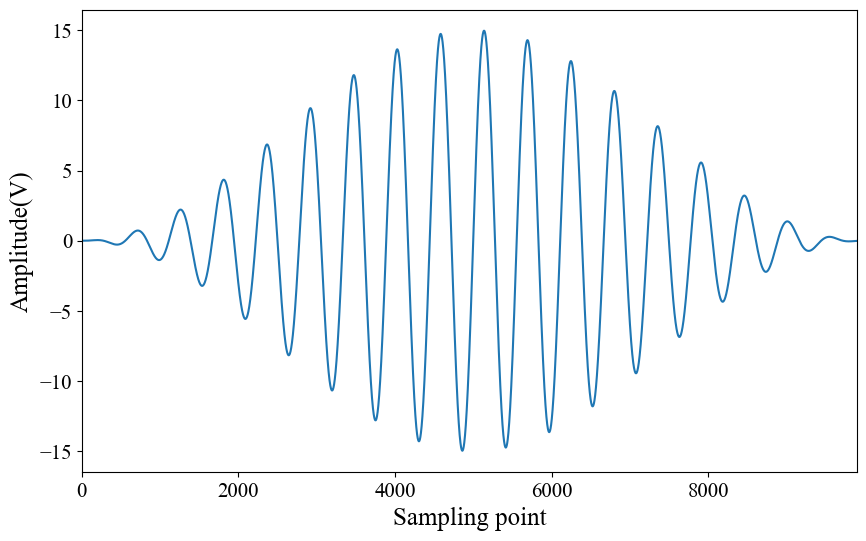

In [7]:
excitation_signals_train_1 = gen_train.reshape(-1,M,1)
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(excitation_signals_train_1[10],linewidth=1.5)
plt.xlabel('Sampling point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(V)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{save_path}Excitation_signal.jpg', dpi=600, bbox_inches='tight')

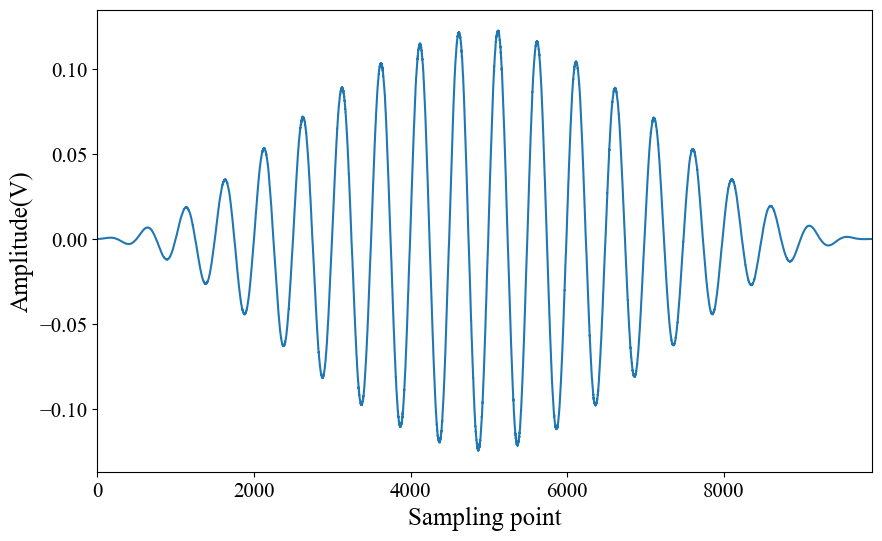

In [8]:
experimental_signal_train_1 = exp_train.reshape(-1,M,1)
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(experimental_signal_train_1[35],linewidth=1.5)
plt.xlabel('Sampling point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(V)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{save_path}Experiment_signal.jpg', dpi=600, bbox_inches='tight')

In [9]:
def calculate_pcc(x, y):
    """
    计算两个信号的皮尔逊相关系数(PCC)。

    参数:
        x (torch.Tensor): 第一个信号，假定在 CUDA 上。
        y (torch.Tensor): 第二个信号，假定在 CUDA 上。

    返回:
        float: 皮尔逊相关系数。
    """
    
    # 计算均值
    mean_x = torch.mean(x)
    mean_y = torch.mean(y)
    
    # 计算协方差
    covariance = torch.mean((x - mean_x) * (y - mean_y))
    
    # 计算标准差
    std_x = torch.std(x)
    std_y = torch.std(y)
    
    # 计算皮尔逊相关系数
    if std_x == 0 or std_y == 0:
        raise ValueError("标准差不能为零，这可能导致除以零的错误。")
    
    pcc = covariance / (std_x * std_y)

    pcc_1 = pcc.to(device)

    return pcc_1.item()  # 将结果转换为 Python 标量

In [10]:
def FFT_Complex_Loss(x, x_hat):
    """
    FFT2损失函数（实部和虚部损失）
    按照公式: J = ||Re(X_hat - X)||^2 + ||Im(X_hat - X)||^2
    
    参数:
    x: 原始信号 [batch_size, channels, length]
    x_hat: 重建信号 [batch_size, channels, length]
    
    返回:
    loss: FFT2损失值
    """
    # 计算FFT
    fft_x = torch.fft.fft(x, dim=-1)          # 原始信号的FFT
    fft_x_hat = torch.fft.fft(x_hat, dim=-1)  # 重建信号的FFT
    
    # 计算频域差异
    fft_diff = fft_x_hat - fft_x
    
    # 提取实部和虚部
    real_diff = torch.real(fft_diff)  # 实部差异
    imag_diff = torch.imag(fft_diff)  # 虚部差异
    
    # 计算L2损失（均方误差）
    real_loss = torch.mean(real_diff ** 2)
    imag_loss = torch.mean(imag_diff ** 2)
    
    # 总损失 = 实部损失 + 虚部损失
    loss = real_loss + imag_loss
    
    return loss.item()

    

In [11]:
def FFT_NP_loss(x, x_hat, fs=2.5e7):
    """
    提取两个频带的最大幅值差异作为损失
    
    参数:
    x: 原始信号 [batch_size, channels, length]
    x_hat: 重建信号 [batch_size, channels, length]
    fs: 采样率,默认为2.5e7 Hz
    
    返回:
    loss: 两个频带最大幅值差异的均方损失
    """
    # 计算FFT
    fft_x = torch.fft.fft(x, dim=-1)
    fft_x_hat = torch.fft.fft(x_hat, dim=-1)
    
    # 获取信号长度
    n_samples = x.shape[-1]
    
    # 计算频率轴
    freqs = torch.fft.fftfreq(n_samples, 1/fs)
    
    # 找到频带对应的索引
    mask_band1 = (freqs >= 48000) & (freqs <= 52000)
    mask_band2 = (freqs >= 95000) & (freqs <= 105000)
    
    # 提取第一个频带(45kHz-55kHz)的最大幅值
    fft_abs_x_band1 = torch.abs(fft_x[..., mask_band1])
    fft_abs_x_hat_band1 = torch.abs(fft_x_hat[..., mask_band1])
    
    # 取最大值
    A1_orig = torch.max(fft_abs_x_band1, dim=-1)[0]
    A1_recon = torch.max(fft_abs_x_hat_band1, dim=-1)[0]
    
    # 提取第二个频带(90kHz-110kHz)的最大幅值
    fft_abs_x_band2 = torch.abs(fft_x[..., mask_band2])
    fft_abs_x_hat_band2 = torch.abs(fft_x_hat[..., mask_band2])
    
    # 取最大值
    A2_orig = torch.max(fft_abs_x_band2, dim=-1)[0]
    A2_recon = torch.max(fft_abs_x_hat_band2, dim=-1)[0]
    
    # 计算幅值差异
    diff_A1 = A1_recon - A1_orig
    diff_A2 = A2_recon - A2_orig
    
    # 计算损失（均方误差）
    loss = torch.mean(diff_A1 ** 2) + torch.mean(diff_A2 ** 2)
    
    return loss.item()  

In [12]:
A = 1
B = 1e-4

# 定义训练和验证函数
def train_model(model, train_loader, valid_loader, epochs, learning_rate, patience):
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    # 添加学习率调度器，每100个epoch衰减为原来的0.8
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
    
    # 早停相关变量 - 使用valid_loss作为监控指标
    best_val = float('inf')  # 更改为监控FFT幅度损失
    patience_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []

    train_PCC=[]
    valid_PCC=[]

    train_FFT_NP=[]
    valid_FFT_NP=[]

    train_FFT_Complex=[]
    valid_FFT_Complex=[]

    train_time =[]
    valid_time =[]

    for epoch in range(epochs):

        train_PCC_2 = 0.0
        train_FFT_2 = 0.0
        train_FFT_3 = 0.0
        train_time_2 = 0.0

        model.train()
        running_loss = 0.0
        for batch in train_loader:
            excitation_signal = batch['excitation_signal'].to(device)
            labels = batch['labels'].to(device)
            experimental_signal = batch['experimental_signal'].to(device)

            optimizer.zero_grad()
            experimental_signal_pred = model(excitation_signal, labels)            

            FFT_NP = FFT_NP_loss(experimental_signal_pred,experimental_signal)
            train_FFT_2 += FFT_NP

            FFT_Complex = FFT_Complex_Loss(experimental_signal_pred,experimental_signal)
            train_FFT_3 += FFT_Complex

            PCC_1 = calculate_pcc(experimental_signal_pred,experimental_signal)
            train_PCC_2 += PCC_1 

            time_loss = criterion(experimental_signal_pred, experimental_signal)
            train_time_2 += time_loss.item()

            loss = A*time_loss + B* FFT_Complex

            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        # 更新学习率
        scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        train_mean_loss = train_time_2 / len(train_loader)
        train_time.append(train_mean_loss)

        train_mean_PCC = train_PCC_2/len(train_loader)
        train_PCC.append(train_mean_PCC)

        train_loss_FFT_NP = train_FFT_2/len(train_loader)
        train_FFT_NP.append(train_loss_FFT_NP)

        train_loss_FFT_Complex = train_FFT_3/len(train_loader)
        train_FFT_Complex.append(train_loss_FFT_Complex)

        model.eval()

        running_loss = 0.0
        valid_PCC_2 = 0.0
        valid_FFT_2 = 0.0
        valid_FFT_3 = 0.0
        valid_time_2=0.0

        with torch.no_grad():
            for batch in valid_loader:
                excitation_signal = batch['excitation_signal'].to(device)
                labels = batch['labels'].to(device)
                experimental_signal = batch['experimental_signal'].to(device)

                experimental_signal_pred = model(excitation_signal, labels)

                PCC_1 = calculate_pcc(experimental_signal_pred,experimental_signal)
                valid_PCC_2 += PCC_1 

                FFT_NP = FFT_NP_loss(experimental_signal_pred,experimental_signal)
                valid_FFT_2 += FFT_NP

                FFT_Complex = FFT_Complex_Loss(experimental_signal_pred,experimental_signal)
                valid_FFT_3 += FFT_Complex

                time_loss = criterion(experimental_signal_pred, experimental_signal)
                valid_time_2 += time_loss.item()

                loss = A*time_loss + B* FFT_Complex

                running_loss += loss.item()
        val_loss = running_loss / len(valid_loader)
        val_losses.append(val_loss)

        val_mean_loss = valid_time_2 / len(valid_loader)
        valid_time.append(val_mean_loss)

        valid_mean_PCC = valid_PCC_2/len(valid_loader)
        valid_PCC.append(valid_mean_PCC)

        valid_loss_FFT_NP = valid_FFT_2/len(valid_loader)
        valid_FFT_NP.append(valid_loss_FFT_NP)

        valid_loss_FFT_Complex = valid_FFT_3/len(valid_loader)
        valid_FFT_Complex.append(valid_loss_FFT_Complex)

        # 早停检查 - 使用valid_loss_FFT_Amp作为监控指标
        if valid_loss_FFT_Complex < best_val:
            best_val = valid_loss_FFT_Complex
            patience_counter = 0
            # 保存最佳模型状态
            best_model_state = model.state_dict().copy()
            print(f"Epoch {epoch+1}: 验证FFT_Complex损失改善 ({valid_loss_FFT_Complex:.4f} -> {best_val:.4f})，保存最佳模型")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n早停触发!连续 {patience} 个epoch验证FFT_Complex损失未改善")
                print(f"最佳验证FFT_Complex损失: {best_val:.4f} (epoch {epoch+1-patience})")
                break

        if epoch % (epochs // 100) == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch: {epoch + 1}/{epochs}, LR: {current_lr:.6f}, Train Loss: {train_mean_loss:.6f}, Val Loss: {val_mean_loss:.6f}")
            print(f"train_loss_FFT_NP: {train_loss_FFT_NP:.4f}, valid_loss_FFT_NP: {valid_loss_FFT_NP:.4f}")
            print(f"train_loss_FFT_Complex: {train_loss_FFT_Complex:.6f}, valid_loss_FFT_Complex: {valid_loss_FFT_Complex:.6f}")
            print(f"train_mean_PCC: {train_mean_PCC:.4f}, valid_mean_PCC: {valid_mean_PCC:.4f}")
            print(f"早停计数器: {patience_counter}/{patience} (监控FFT_Complex损失)")

    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n训练完成, 加载最佳模型(验证FFT_Complex损失: {best_val:.4f})")
    else:
        print("\n训练完成, 但未找到最佳模型")
    
    return (train_time, valid_time, train_PCC, valid_PCC, 
            train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP)


In [13]:
# 训练模型
epochs = 3000 
lr = 1e-3
model = ConvAutoencoder(signal_length = M, label_dim = label_dim, hidden_dim = 16, dropout = 0).to(device)
train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP = train_model(
    model, train_loader, valid_loader, epochs=epochs, learning_rate=lr, patience=500)

Epoch 1: 验证FFT_Complex损失改善 (342.5126 -> 342.5126)，保存最佳模型
Epoch: 1/3000, LR: 0.001000, Train Loss: 0.055662, Val Loss: 0.034597
train_loss_FFT_NP: 227881.1406, valid_loss_FFT_NP: 193298.2500
train_loss_FFT_Complex: 551.054108, valid_loss_FFT_Complex: 342.512614
train_mean_PCC: -0.0001, valid_mean_PCC: -0.0003
早停计数器: 0/500 (监控FFT_Complex损失)
Epoch 4: 验证FFT_Complex损失改善 (220.4913 -> 220.4913)，保存最佳模型
Epoch 5: 验证FFT_Complex损失改善 (96.0071 -> 96.0071)，保存最佳模型
Epoch 9: 验证FFT_Complex损失改善 (75.1354 -> 75.1354)，保存最佳模型
Epoch 11: 验证FFT_Complex损失改善 (67.7935 -> 67.7935)，保存最佳模型
Epoch 12: 验证FFT_Complex损失改善 (60.1281 -> 60.1281)，保存最佳模型
Epoch 14: 验证FFT_Complex损失改善 (58.2863 -> 58.2863)，保存最佳模型
Epoch 15: 验证FFT_Complex损失改善 (55.8534 -> 55.8534)，保存最佳模型
Epoch 16: 验证FFT_Complex损失改善 (54.6849 -> 54.6849)，保存最佳模型
Epoch 17: 验证FFT_Complex损失改善 (52.9803 -> 52.9803)，保存最佳模型
Epoch 18: 验证FFT_Complex损失改善 (51.8622 -> 51.8622)，保存最佳模型
Epoch 19: 验证FFT_Complex损失改善 (50.9975 -> 50.9975)，保存最佳模型
Epoch 21: 验证FFT_Complex损失改善 (50.8011 -> 50.8

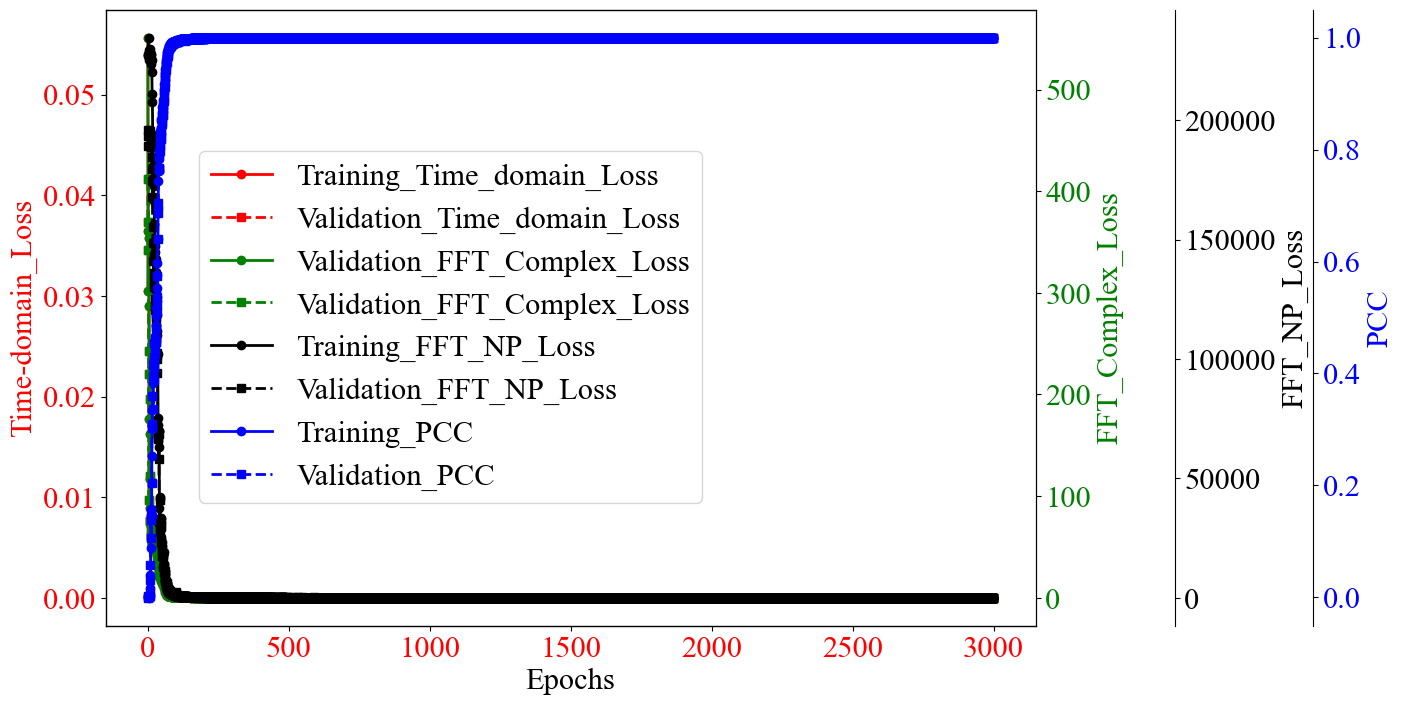

In [14]:
def Forward_Model_Loss(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP, font='Times new roman', font_size=22, line_width=2):
    """
    绘制训练和验证损失函数图,并同时绘制PCC和FFT值。

    参数：
    train_losses (list): 训练损失值列表。
    val_losses (list): 验证损失值列表。
    train_pccs (list): 训练PCC值列表。
    valid_pccs (list): 验证PCC值列表。
    train_ffts (list): 训练FFT值列表。
    valid_ffts (list): 验证FFT值列表。
    font (str): 字体，默认为 'Arial'。
    font_size (int): 字号，默认为 12。
    line_width (float): 线条粗细，默认为 2。
    """

    # 创建主图
    plt.figure(figsize=(12, 8))
    ax1 = plt.gca()  # 获取当前主图的轴对象

    # 绘制损失
    ax1.plot(train_losses, label='Training_Time_domain_Loss', color='red', linewidth=line_width, marker='o')
    ax1.plot(val_losses, label='Validation_Time_domain_Loss', color='red', linewidth=line_width, linestyle='--', marker='s')

    # 设置主图的标签和标题
    ax1.set_xlabel('Epochs', fontname=font, fontsize=font_size)
    ax1.set_ylabel('Time-domain_Loss', fontname=font, fontsize=font_size, color='red')
    ax1.tick_params(axis='both', which='major',labelcolor='red', labelsize=font_size)

    # 创建第二个Y轴
    ax2 = ax1.twinx()
    ax2.plot(train_FFT_Complex, label='Validation_FFT_Complex_Loss', color='green', linewidth=line_width, marker='o')
    ax2.plot(valid_FFT_Complex, label='Validation_FFT_Complex_Loss', color='green', linewidth=line_width, linestyle='--', marker='s')
    ax2.set_ylabel('FFT_Complex_Loss', fontname=font, fontsize=font_size, color='green')
    ax2.tick_params(axis='y', which='major',labelcolor='green', labelsize=font_size)

    # 创建第三个Y轴
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 100))  # 将第三个Y轴向右移动
    ax3.plot(train_FFT_NP, label='Training_FFT_NP_Loss', color='black', linewidth=line_width, marker='o')
    ax3.plot(valid_FFT_NP, label='Validation_FFT_NP_Loss', color='black', linewidth=line_width, linestyle='--', marker='s')
    ax3.set_ylabel('FFT_NP_Loss', fontname=font, fontsize=font_size, color='black')
    ax3.tick_params(axis='y', which='major',labelcolor='black', labelsize=font_size)

    # 创建第四个Y轴
    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 200))  # 将第四个Y轴向右移动
    ax4.plot(train_PCC, label='Training_PCC', color='blue', linewidth=line_width, marker='o')
    ax4.plot(valid_PCC, label='Validation_PCC', color='blue', linewidth=line_width, linestyle='--', marker='s')
    ax4.set_ylabel('PCC', fontname=font, fontsize=font_size, color='blue')
    ax4.tick_params(axis='y', which='major',labelcolor='blue', labelsize=font_size)

    # 将图例放在一起
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    ax1.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, loc=(0.1,0.2), fontsize=font_size)

    # 保存图像
    plt.savefig(f'{save_path}Forward_Model_FFT_Complex_Loss.jpg', dpi=300, bbox_inches='tight')
    plt.show()

# 调用函数，传入你的数据
Forward_Model_Loss(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP)

In [15]:
torch.save(model, f'{save_path}Forward_Model_FFT_Complex.pth') 
print("模型已保存")

模型已保存


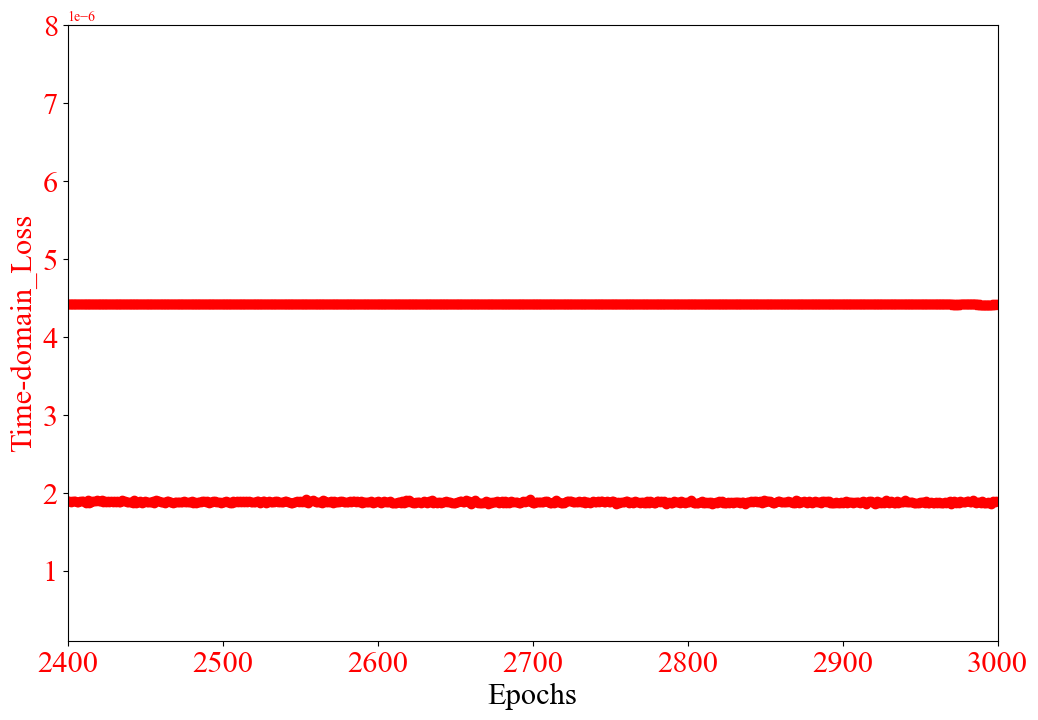

In [19]:
def Model_Loss_Enlargement_Time(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP, font='Times new roman', font_size=22, line_width=2):
    """
    绘制训练和验证损失函数图,并同时绘制PCC和FFT值。

    参数：
    train_losses (list): 训练损失值列表。
    val_losses (list): 验证损失值列表。
    train_pccs (list): 训练PCC值列表。
    valid_pccs (list): 验证PCC值列表。
    train_ffts (list): 训练FFT值列表。
    valid_ffts (list): 验证FFT值列表。
    font (str): 字体，默认为 'Arial'。
    font_size (int): 字号，默认为 12。
    line_width (float): 线条粗细，默认为 2。
    """
    # 创建主图
    plt.figure(figsize=(12, 8))
    ax1 = plt.gca()  # 获取当前主图的轴对象

    # 绘制损失
    ax1.plot(train_losses, label='Training_Time-domain Loss', color='red', linewidth=line_width, marker='o')
    ax1.plot(val_losses, label='Validation_Time-domain Loss', color='red', linewidth=line_width, linestyle='--', marker='s')

    # 设置主图的标签和标题
    ax1.set_xlabel('Epochs', fontname=font, fontsize=font_size)
    ax1.set_ylabel('Time-domain_Loss', fontname=font, fontsize=font_size, color='red')
    ax1.tick_params(axis='both', which='major',labelcolor='red', labelsize=font_size)
    plt.xlim(epochs*0.8,epochs)
    plt.ylim(1e-7,0.8e-5)

    # 保存图像
    plt.savefig(f'{save_path}Time_Loss_Enlargement_FFT_Complex.jpg', dpi=300, bbox_inches='tight')
    plt.show()

# 调用函数，传入你的数据
Model_Loss_Enlargement_Time(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP)

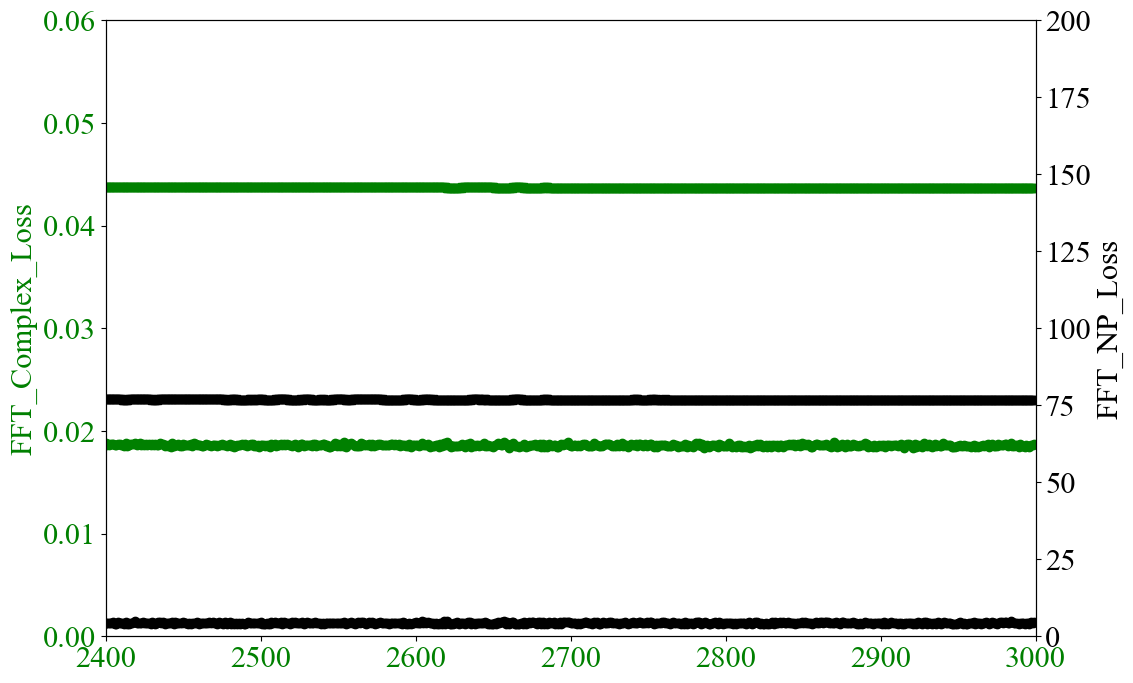

In [28]:
def Model_Loss_Enlargement_Frequency(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP, font='Times new roman', font_size=22, line_width=2):
    """
    绘制训练和验证损失函数图,并同时绘制PCC和FFT值。

    参数：
    train_losses (list): 训练损失值列表。
    val_losses (list): 验证损失值列表。
    train_pccs (list): 训练PCC值列表。
    valid_pccs (list): 验证PCC值列表。
    train_ffts (list): 训练FFT值列表。
    valid_ffts (list): 验证FFT值列表。
    font (str): 字体，默认为 'Arial'。
    font_size (int): 字号，默认为 12。
    line_width (float): 线条粗细，默认为 2。
    """
    # 创建主图
    plt.figure(figsize=(12, 8))
    ax1 = plt.gca()  # 获取当前主图的轴对象
    ax1.plot(train_FFT_Complex, label='Training_FFT_Complex_Loss', color='green', linewidth=line_width, marker='o')
    ax1.plot(valid_FFT_Complex, label='Validation_FFT_Complex_Loss', color='green', linewidth=line_width, linestyle='--', marker='s')
    ax1.set_ylabel('FFT_Complex_Loss', fontname=font, fontsize=font_size, color='green')
    ax1.tick_params(axis='x', which='major',labelcolor='green', labelsize=font_size)
    ax1.tick_params(axis='y', which='major',labelcolor='green', labelsize=font_size)
    plt.xlim(epochs*0.8,epochs)
    plt.ylim(0,6e-2)

    ax2 = ax1.twinx()
    ax2.plot(train_FFT_NP, label='Training_FFT_NP_Loss', color='black', linewidth=line_width, marker='o')
    ax2.plot(valid_FFT_NP, label='Validation_FFT_NP_Loss', color='black', linewidth=line_width, linestyle='--', marker='s')
    ax2.set_ylabel('FFT_NP_Loss', fontname=font, fontsize=font_size, color='black')
    ax2.tick_params(axis='y', which='major',labelcolor='black', labelsize=font_size)
    plt.xlim(epochs*0.8,epochs)
    plt.ylim(0,2e2)

    # 保存图像
    plt.savefig(f'{save_path}FFT_Loss_Enlargement_FFT_Complex.jpg', dpi=300, bbox_inches='tight')
    plt.show()

# 调用函数，传入你的数据
Model_Loss_Enlargement_Frequency(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP)

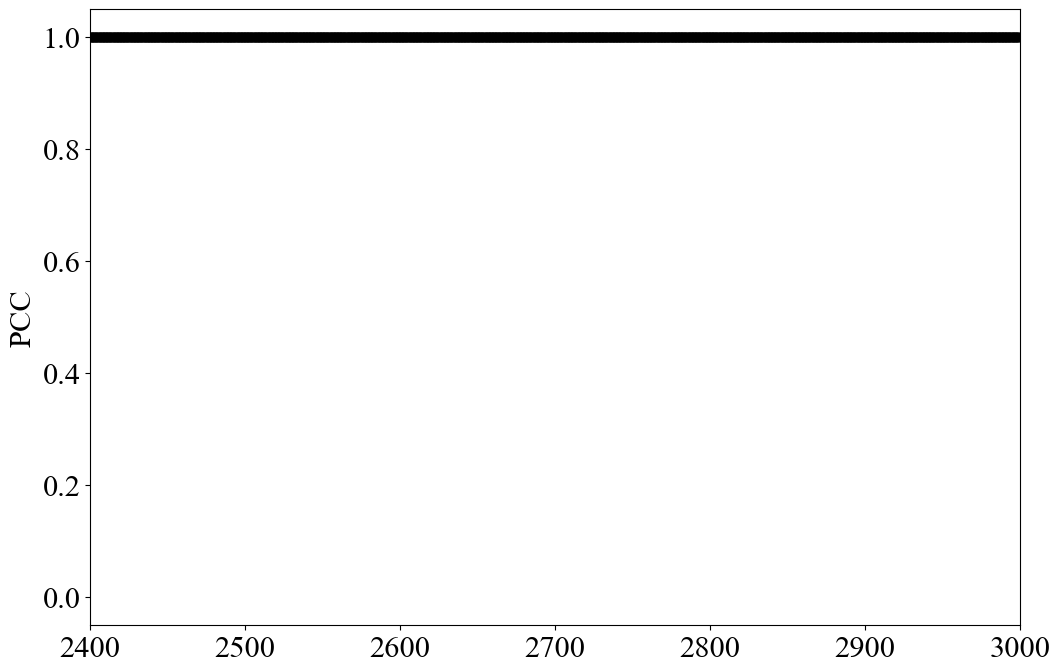

In [29]:
def Model_Loss_Enlargement_PCC(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP, font='Times new roman', font_size=22, line_width=2):
    """
    绘制训练和验证损失函数图,并同时绘制PCC和FFT值。

    参数：
    train_losses (list): 训练损失值列表。
    val_losses (list): 验证损失值列表。
    train_pccs (list): 训练PCC值列表。
    valid_pccs (list): 验证PCC值列表。
    train_ffts (list): 训练FFT值列表。
    valid_ffts (list): 验证FFT值列表。
    font (str): 字体，默认为 'Arial'。
    font_size (int): 字号，默认为 12。
    line_width (float): 线条粗细，默认为 2。
    """
    # 创建主图
    plt.figure(figsize=(12, 8))
    ax1 = plt.gca()  # 获取当前主图的轴对象
    ax1.plot(train_PCC, label='Training PCC', color='black', linewidth=line_width, marker='o')
    ax1.plot(valid_PCC, label='Validation PCC', color='black', linewidth=line_width, linestyle='--', marker='s')
    ax1.set_ylabel('PCC', fontname=font, fontsize=font_size, color='black')
    ax1.tick_params(axis='x', which='major',labelcolor='black', labelsize=font_size)
    ax1.tick_params(axis='y', which='major',labelcolor='black', labelsize=font_size)

    plt.xlim(epochs*0.8,epochs)
    #plt.ylim(0.9998,1)

    # 保存图像
    plt.savefig(f'{save_path}PCC_Loss_Enlargement_FFT_Complex.jpg', dpi=300, bbox_inches='tight')
    plt.show()

# 调用函数，传入你的数据
Model_Loss_Enlargement_PCC(train_losses, val_losses, train_PCC, valid_PCC, train_FFT_Complex, valid_FFT_Complex, train_FFT_NP, valid_FFT_NP)